In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("single_genre_artists.csv")

df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [3]:
df.shape

(95837, 23)

In [4]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

In [6]:
df.describe()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


In [7]:
df.isnull().sum()

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
drop_cols = ['track_id', 'track_name', 'artist_name']

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [11]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

X = df[features]

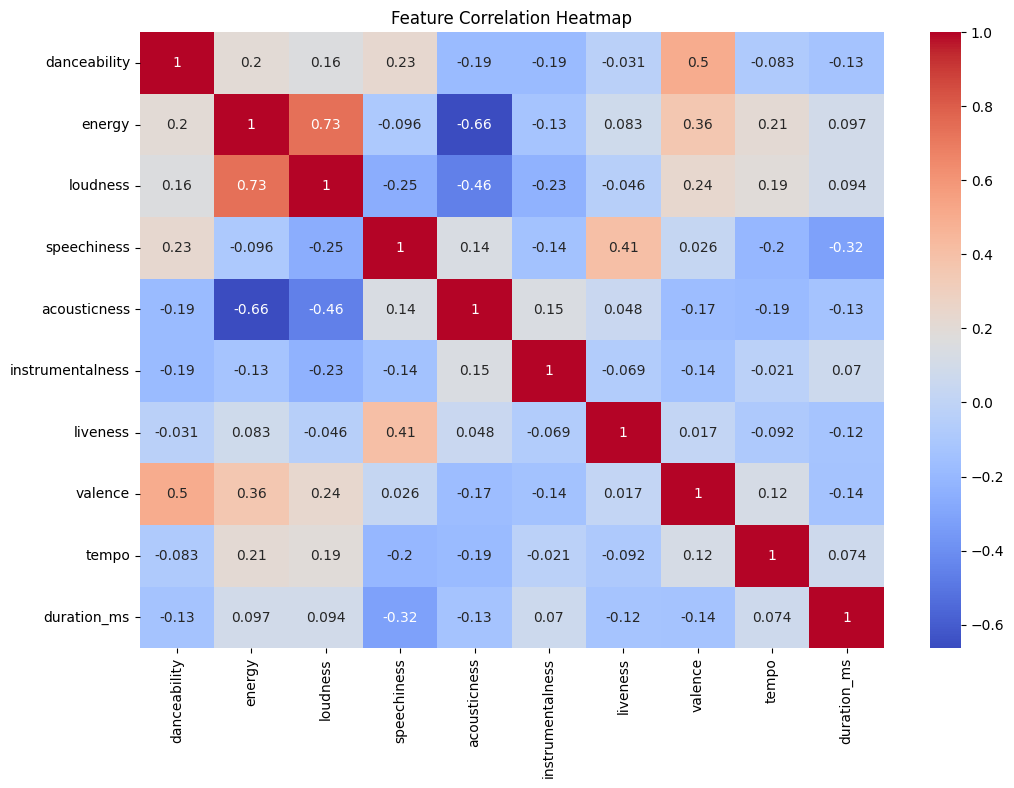

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

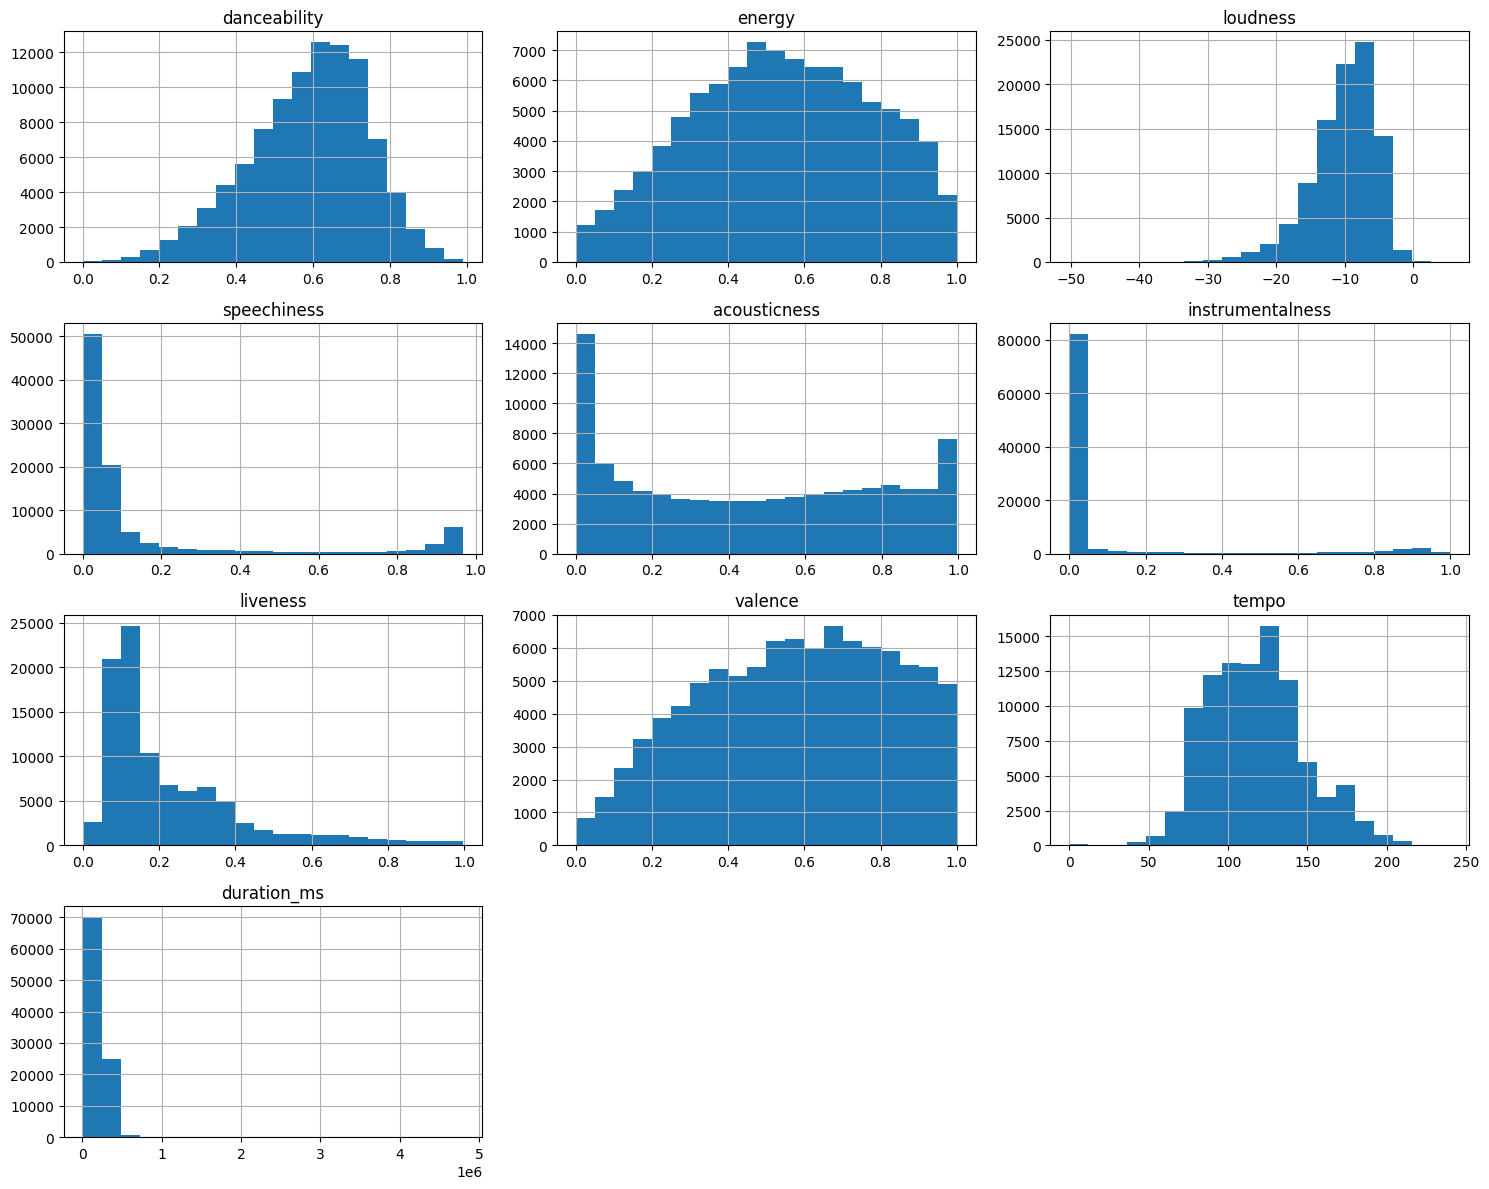

In [13]:
X.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
X_scaled

array([[-0.15347598, -1.51112816, -0.75790895, ...,  0.32128698,
         0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, ..., -0.57745518,
        -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, ..., -0.37594348,
        -1.56000306, -0.00394925],
       ...,
       [ 0.14249425, -2.21700341, -3.87787243, ...,  1.27242218,
        -1.62041993, -1.07201656],
       [-0.15991012, -2.14971674, -3.24149759, ..., -0.7588157 ,
        -1.78348586, -0.19941949],
       [-0.17277839, -0.09768491,  0.56580125, ..., -1.46410663,
         0.47552221,  0.4206722 ]], shape=(95837, 10))

In [16]:
inertia = []

k_range = range(1, 11)

for k in k_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

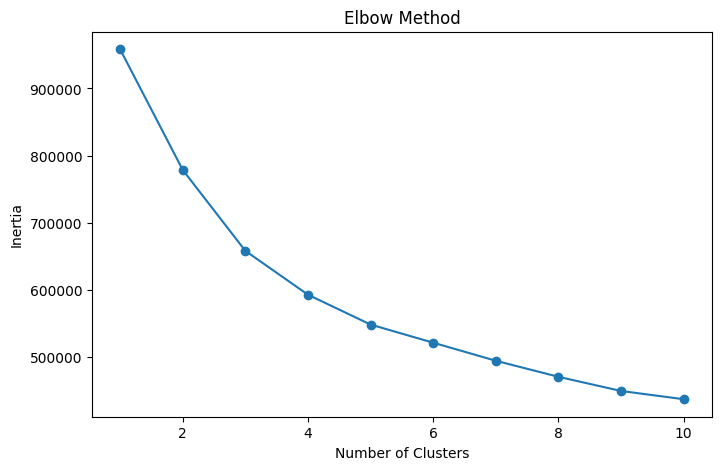

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [18]:
n_clusters = 4

In [19]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [20]:
df['Cluster'] = clusters

df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,Cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22,3
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22,3
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22,3
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22,3
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22,3


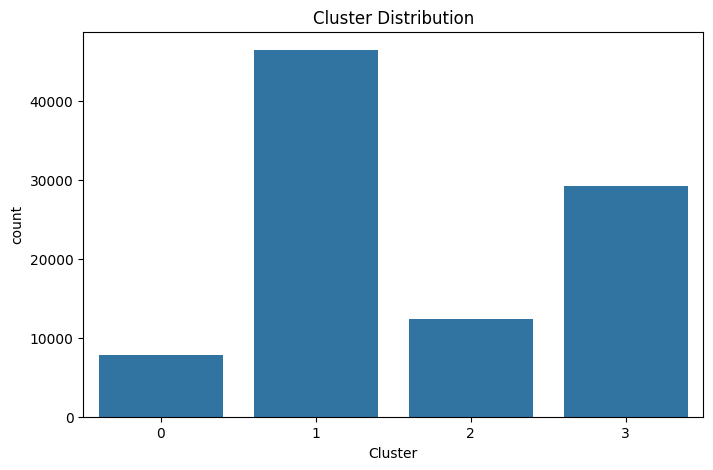

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['Cluster'])

plt.title("Cluster Distribution")

plt.show()

In [30]:
from sklearn.metrics import silhouette_score

sample_data = X_scaled[:5000]
sample_clusters = clusters[:5000]

score = silhouette_score(
    sample_data,
    sample_clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.19258860638673772


In [24]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

In [25]:
pca_df = pd.DataFrame(
    pca_features,
    columns=['PCA1', 'PCA2']
)

pca_df['Cluster'] = clusters

pca_df.head()

,PCA1,PCA2,Cluster
0,-1.676304,0.291571,3
1,-2.639968,-0.472803,3
2,-2.537328,0.474464,3
3,-0.677418,0.709757,3
4,-1.480657,1.426716,3


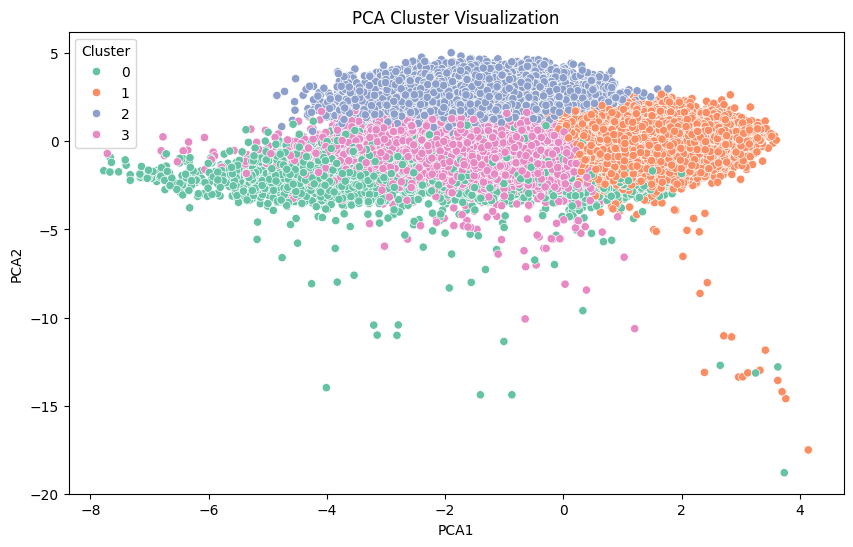

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2',
    data=pca_df
)

plt.title("PCA Cluster Visualization")

plt.show()

In [32]:
cluster_profile = df.groupby('Cluster')[features].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
Cluster,,,,,,,,,,
0,0.485341,0.415775,-13.954724,0.059929,0.646652,0.810613,0.188557,0.449986,114.301014,231386.462428
1,0.634711,0.707636,-7.416184,0.077040,0.242192,0.021039,0.201125,0.685616,125.294702,224649.058878
2,0.664340,0.466488,-13.385665,0.834554,0.585597,0.000975,0.435223,0.583509,100.336080,96913.082601
3,0.505186,0.341825,-12.120023,0.060990,0.699190,0.017446,0.183097,0.426877,113.401800,224876.823023


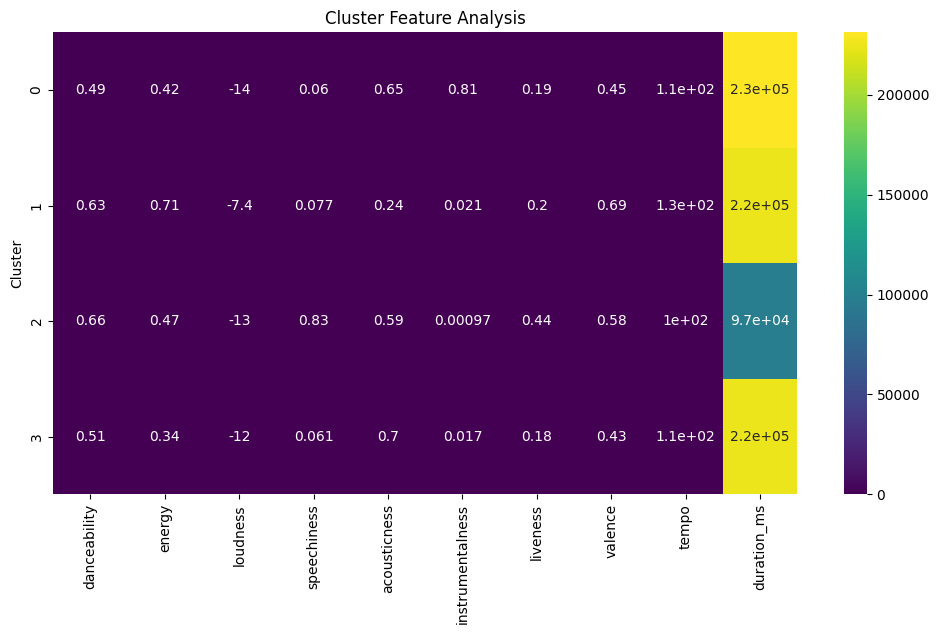

In [33]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='viridis'
)

plt.title("Cluster Feature Analysis")

plt.show()

In [35]:
cluster_names = {
    0: "Dance Party",
    1: "Acoustic Chill",
    2: "High Energy Tracks",
    3: "Instrumental Vibes"
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

In [36]:
df[['Cluster', 'Cluster_Name']].head()

,Cluster,Cluster_Name
0,3,Instrumental Vibes
1,3,Instrumental Vibes
2,3,Instrumental Vibes
3,3,Instrumental Vibes
4,3,Instrumental Vibes


In [37]:
df.to_csv(
    'clustered_songs.csv',
    index=False
)

print("File Saved Successfully")

File Saved Successfully
